# VertexCBF — examples

This notebook walks through the whole VertexCBF pipeline on a small system, using the
library directly (no YAML, no scripts), and then shows how to use the result:

1. [System and constraint](#1.-System-and-constraint)
2. [Supervision labels via vertex-restricted beam search](#2.-Supervision-labels-via-vertex-restricted-beam-search)
3. [Training the neural CBF](#3.-Training-the-neural-CBF)
4. [Inspecting the learned CBF](#4.-Inspecting-the-learned-CBF)
5. [Closed-loop validation](#5.-Closed-loop-validation)
6. [Using the CBF in a safety filter](#6.-Using-the-CBF-in-a-safety-filter)
7. [Working with YAML configs and checkpoints](#7.-Working-with-YAML-configs-and-checkpoints)
8. [Extending: your own system and constraint](#8.-Extending:-your-own-system-and-constraint)

**The method in one paragraph.** We learn a neural approximation $V_\Theta(x)$ of the
stationary Hamilton–Jacobi safety value function and use it as a control barrier function
(CBF). The network is parametrised as a residual, $V_\Theta(x) = c(x) - r_\Theta(x)$ with
$r_\Theta \ge 0$, so the learned safe set $\{V_\Theta \ge 0\}$ can never exceed the
constraint set $\{c \ge 0\}$. Training combines a physics-informed loss (the stationary
HJB variational inequality) with sparse supervision. Because the dynamics are
control-affine and the control set is a box, the Hamiltonian is maximised at a *vertex*
of the control box — so supervision labels can be computed by a GPU-parallel tree search
restricted to the control vertices, with no PDE solver and no continuous trajectory
optimisation.

The whole notebook runs in well under a minute on a GPU; on CPU expect a few minutes.

In [1]:
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D

from vertexcbf import (
    MLP,
    DoubleIntegrator1D,
    Trainer,
    beam_search,
    interval_sdf,
    stratified_sample_by_predicted_cbf,
    validate_cbf,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
np.random.seed(0)

# Repository root (works whether the kernel starts in notebooks/ or the repo root).
REPO = Path.cwd().resolve()
REPO = REPO.parent if REPO.name == "notebooks" else REPO

# Fixed colours for the recurring overlays.
C_CONSTRAINT = "black"      # c(x) = 0
C_TRUE = "#eb6834"          # analytical safe-set boundary
C_LEARNED = "#2a78d6"       # V_Θ(x) = 0
C_VALIDATED = "#1baf7a"     # closed-loop validated boundary
C_UNSAFE = "#e34948"
CMAP_V = "RdBu"             # diverging, centred at 0: red = unsafe, blue = safe

print(f"device: {device}")

device: cuda


## 1. System and constraint

Every system is a `ControlAffine` subclass exposing the drift `f(x)` and the control
matrix `g(x)` of $\dot x = f(x) + g(x)\,u$, together with a state box
$[x_{\min}, x_{\max}]$ and a control box $[u_{\min}, u_{\max}]$.
The constraint $c(x)$ is any differentiable function with $\{c \ge 0\}$ the allowed
region — here a plain signed distance to an interval.

We use the 1-D double integrator ($p$ = position, $v$ = velocity, $u$ = acceleration)
with $|p| \le 1$ and $|u| \le 0.5$. It is small enough to plot everything and it has an
analytical answer to compare against: a state is truly safe iff the vehicle can still stop
before the wall under maximal braking, i.e. $|p + v|v| / (2 u_{\max})| \le 1$.

nx=2, nu=1
control vertices (nu x 2^nu):
 tensor([[-0.5000,  0.5000]], device='cuda:0')


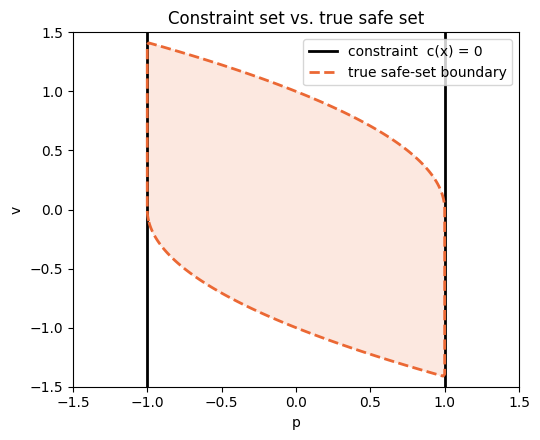

In [2]:
U_MAX = 0.5   # acceleration limit
D = 1.0       # half-width of the allowed position interval

dyn = DoubleIntegrator1D(
    x_min=[-1.5, -1.5], x_max=[1.5, 1.5],
    u_min=[-U_MAX], u_max=[U_MAX],
    device=device,
)
constr_fn = partial(interval_sdf, center=0.0, d=D)

print(f"nx={dyn.nx}, nu={dyn.nu}")
print("control vertices (nu x 2^nu):\n", dyn.get_control_vertices())


def true_safe_margin(x: np.ndarray) -> np.ndarray:
    # Positive inside the true (maximal control-invariant) safe set, negative outside.
    p, v = x[..., 0], x[..., 1]
    stop = p + v * np.abs(v) / (2 * U_MAX)       # where the vehicle comes to rest under max braking
    return np.minimum.reduce([D - np.abs(p), D - stop, D + stop])


def state_grid(n: int = 200):
    # (n, n, nx) numpy grid over the state box + the same states as a flat torch tensor.
    g = dyn.get_uniform_state_grid([n, n]).cpu().numpy()
    return g, torch.as_tensor(g.reshape(-1, dyn.nx), device=device)


G, G_t = state_grid()
constr_on_grid = constr_fn(G_t).reshape(G.shape[:2]).cpu().numpy()
true_on_grid = true_safe_margin(G)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.contourf(G[..., 0], G[..., 1], true_on_grid, levels=[0, 1e9], colors=[C_TRUE], alpha=0.15)
ax.contour(G[..., 0], G[..., 1], constr_on_grid, levels=[0], colors=C_CONSTRAINT, linewidths=2)
ax.contour(G[..., 0], G[..., 1], true_on_grid, levels=[0], colors=C_TRUE, linewidths=2, linestyles="--")
ax.legend(handles=[
    Line2D([], [], color=C_CONSTRAINT, lw=2, label="constraint  c(x) = 0"),
    Line2D([], [], color=C_TRUE, lw=2, ls="--", label="true safe-set boundary"),
], loc="upper right")
ax.set_xlabel("p"); ax.set_ylabel("v"); ax.set_title("Constraint set vs. true safe set")
plt.tight_layout(); plt.show()

## 2. Supervision labels via vertex-restricted beam search

For control-affine dynamics and a box control set, the Hamiltonian
$\max_u \nabla V \cdot (f(x) + g(x)u)$ is attained at a vertex of the box. VertexCBF
therefore generates supervision labels by searching over sequences of **control
vertices** only: for each initial state it looks for the vertex sequence that maximises
$\min_{k \le K} c(x_k)$ along an Euler rollout, and uses that optimum as the label
(positive ⇒ a $K$-step-safe control sequence exists, negative ⇒ none was found).

`beam_search` does this for a whole batch of initial states in parallel on the GPU. `B` is
the beam width, `K` the horizon in steps, `dt` the Euler step. The other vertex-restricted
searches (`stochastic_beam_search`, `branch_and_bound`, `cem_discrete`) share the same
call signature.

In [10]:
states_d = dyn.get_uniform_state_grid([41, 41]).reshape(-1, dyn.nx)

search = beam_search(
    dynamics=dyn, x0=states_d, constr_fn=constr_fn,
    B=1000, K=40, dt=0.1,
    return_trajs=True,           # also return the best vertex sequence per state
)
values_d = search["values"]      # (N,)  supervision labels
print(f"{states_d.shape[0]} labels, range [{values_d.min():.3f}, {values_d.max():.3f}], "
      f"{(values_d > 0).float().mean() * 100:.1f}% labelled safe")

1681 labels, range [-2.825, 0.995], 37.7% labelled safe


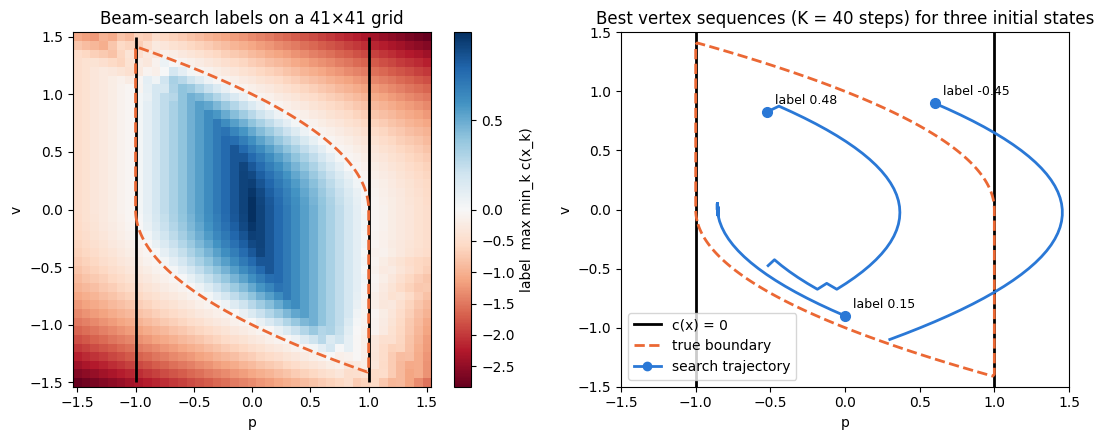

control sequence of the first trajectory (only ±u_max appear):
 [ 0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5]


In [11]:
labels_grid = values_d.reshape(41, 41).cpu().numpy()
grid_d = states_d.reshape(41, 41, dyn.nx).cpu().numpy()
norm = TwoSlopeNorm(vmin=min(labels_grid.min(), -1e-3), vcenter=0.0, vmax=max(labels_grid.max(), 1e-3))

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

im = ax.pcolormesh(grid_d[..., 0], grid_d[..., 1], labels_grid, cmap=CMAP_V, norm=norm, shading="nearest")
ax.contour(G[..., 0], G[..., 1], constr_on_grid, levels=[0], colors=C_CONSTRAINT, linewidths=2)
ax.contour(G[..., 0], G[..., 1], true_on_grid, levels=[0], colors=C_TRUE, linewidths=2, linestyles="--")
fig.colorbar(im, ax=ax, label="label  max min_k c(x_k)")
ax.set_xlabel("p"); ax.set_ylabel("v"); ax.set_title("Beam-search labels on a 41×41 grid")

# A few of the optimal vertex-restricted trajectories (bang-bang by construction).
picks = [np.argmin(np.linalg.norm(states_d.cpu().numpy() - np.array(x0), axis=1))
         for x0 in [(-0.5, 0.8), (0.0, -0.9), (0.6, 0.9)]]   # two truly safe, one not
traj = search["state_traj"][picks].cpu().numpy()       # (3, K+1, nx)
ctrl = search["control_traj"][picks].cpu().numpy()     # (3, K, nu)
ax2.contour(G[..., 0], G[..., 1], constr_on_grid, levels=[0], colors=C_CONSTRAINT, linewidths=2)
ax2.contour(G[..., 0], G[..., 1], true_on_grid, levels=[0], colors=C_TRUE, linewidths=2, linestyles="--")
for i, tr in enumerate(traj):
    ax2.plot(tr[:, 0], tr[:, 1], "-", color=C_LEARNED, lw=2)
    ax2.plot(tr[0, 0], tr[0, 1], "o", color=C_LEARNED, ms=7)
    ax2.annotate(f"label {values_d[picks[i]]:.2f}", tr[0], textcoords="offset points", xytext=(6, 6), fontsize=9)
ax2.set_xlim(dyn.x_min[0].item(), dyn.x_max[0].item()); ax2.set_ylim(dyn.x_min[1].item(), dyn.x_max[1].item())
ax2.set_xlabel("p"); ax2.set_ylabel("v"); ax2.set_title("Best vertex sequences (K = 40 steps) for three initial states")
ax2.legend(handles=[
    Line2D([], [], color=C_CONSTRAINT, lw=2, label="c(x) = 0"),
    Line2D([], [], color=C_TRUE, lw=2, ls="--", label="true boundary"),
    Line2D([], [], color=C_LEARNED, lw=2, marker="o", label="search trajectory"),
], loc="lower left")
plt.tight_layout(); plt.show()

print("control sequence of the first trajectory (only ±u_max appear):\n", ctrl[0, :12, 0])

## 3. Training the neural CBF

The model predicts the **residual** $r_\Theta(x) \ge 0$; the CBF is
$V_\Theta(x) = c(x) - r_\Theta(x)$. A `softplus` output activation enforces the sign, so
$V_\Theta \le c$ holds by construction. Sinusoidal hidden activations work well for these
smooth value functions; periodic states (angles) would be encoded as $(\cos, \sin)$
automatically via `periodic_inputs`.

`Trainer` minimises

$$\mathcal{L} = w\,\mathcal{L}_{\text{PDE}} + (1 - w)\,\mathcal{L}_{\text{data}},$$

where $\mathcal{L}_{\text{PDE}}$ penalises the stationary HJB variational inequality on a
set of collocation states (`pde_grid_shape` or `pde_num_samples`) and
$\mathcal{L}_{\text{data}}$ regresses $V_\Theta$ onto the labels from Section 2.
`pde_weight_mode="normalized"` divides each term by its initial value instead of using a
fixed $w$.

Epoch [   500/3000]  loss=0.214066  pde=0.195883  data=0.377712
Epoch [  1000/3000]  loss=0.007986  pde=0.006877  data=0.017965
Epoch [  1500/3000]  loss=0.003266  pde=0.001671  data=0.017619
Epoch [  2000/3000]  loss=0.002447  pde=0.000730  data=0.017903
Epoch [  2500/3000]  loss=0.002400  pde=0.000690  data=0.017787
Epoch [  3000/3000]  loss=0.002378  pde=0.000667  data=0.017778


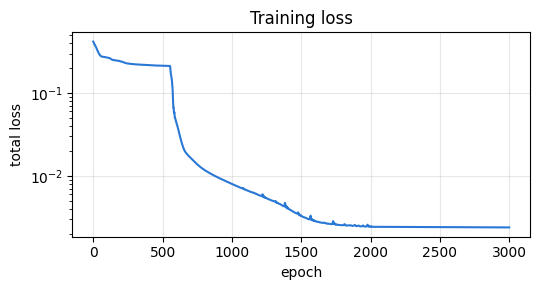

In [12]:
model = MLP(
    layers_config=[(dyn.nx, None), (32, "sin"), (32, "sin"), (32, "sin"), (32, "sin"), (1, ("softplus", {"beta": 10.0}))],
    input_min=dyn.x_min, input_max=dyn.x_max,
    periodic_inputs=dyn.periodic_states,   # [] for this system
).to(device)

trainer = Trainer(
    dynamics=dyn, model=model, constr_fn=constr_fn,
    epochs=3000, lr=1e-3, lr_milestones=[2000], lr_gamma=0.1,
    pde_grid_shape=(100, 100),
    pde_weight_mode="fixed", pde_weight=0.9,
    data_states=states_d, data_values=values_d,
    log_every=500,
    # checkpoint_dir="checkpoints/tutorial",   # optional: periodic + final checkpoints
)
losses = trainer.train()

fig, ax = plt.subplots(figsize=(5.5, 3))
ax.semilogy(losses, color=C_LEARNED, lw=1.5)
ax.set_xlabel("epoch"); ax.set_ylabel("total loss"); ax.set_title("Training loss")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 4. Inspecting the learned CBF

The model itself returns the residual; the CBF value is always
`constr_fn(x) - model(x)`. Below we evaluate it on a dense grid and compare its zero-level
set with the constraint and with the analytical safe-set boundary.

safe-set sign agreement with the analytical solution: 99.62%
max V_Θ - c over the grid: -2.73e-06   (≤ 0 by construction)


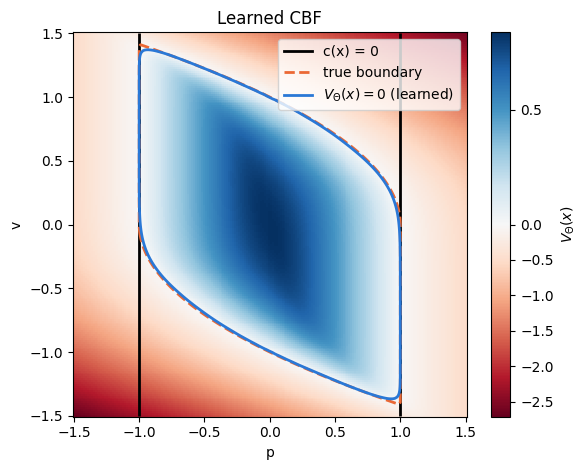

In [13]:
def cbf(x: torch.Tensor) -> torch.Tensor:
    # V_Θ(x) = c(x) - r_Θ(x), for a batch x of shape (N, nx) → (N,)
    return (constr_fn(x) - model(x)).squeeze(-1)


with torch.no_grad():
    V_grid = cbf(G_t).reshape(G.shape[:2]).cpu().numpy()

sign_agreement = np.mean((V_grid > 0) == (true_on_grid > 0)) * 100
print(f"safe-set sign agreement with the analytical solution: {sign_agreement:.2f}%")
print(f"max V_Θ - c over the grid: {np.max(V_grid - constr_on_grid):.2e}   (≤ 0 by construction)")

norm = TwoSlopeNorm(vmin=V_grid.min(), vcenter=0.0, vmax=V_grid.max())
fig, ax = plt.subplots(figsize=(6, 4.8))
im = ax.pcolormesh(G[..., 0], G[..., 1], V_grid, cmap=CMAP_V, norm=norm, shading="auto", rasterized=True)
ax.contour(G[..., 0], G[..., 1], constr_on_grid, levels=[0], colors=C_CONSTRAINT, linewidths=2)
ax.contour(G[..., 0], G[..., 1], true_on_grid, levels=[0], colors=C_TRUE, linewidths=2, linestyles="--")
ax.contour(G[..., 0], G[..., 1], V_grid, levels=[0], colors=C_LEARNED, linewidths=2)
fig.colorbar(im, ax=ax, label=r"$V_\Theta(x)$")
ax.legend(handles=[
    Line2D([], [], color=C_CONSTRAINT, lw=2, label="c(x) = 0"),
    Line2D([], [], color=C_TRUE, lw=2, ls="--", label="true boundary"),
    Line2D([], [], color=C_LEARNED, lw=2, label=r"$V_\Theta(x) = 0$ (learned)"),
], loc="upper right")
ax.set_xlabel("p"); ax.set_ylabel("v"); ax.set_title("Learned CBF")
plt.tight_layout(); plt.show()

## 5. Closed-loop validation

A CBF is only useful if the safe set it predicts is actually forward-invariant under some
admissible controller. `validate_cbf` rolls out the *Hamiltonian-greedy* policy
$u^*(x) = \arg\max_u \nabla V_\Theta(x) \cdot (f(x) + g(x) u)$ (always a control vertex)
from a batch of initial states and compares the prediction $V_\Theta(x_0) > 0$ with what
actually happened, $\min_k c(x_k) > 0$. It reports two conditional rates:

* **false-safe rate** — $P(\text{violated} \mid V_\Theta(x_0) > 0)$, the safety-critical number;
* **false-unsafe rate** — $P(\text{safe} \mid V_\Theta(x_0) \le 0)$, the conservativeness.

`stratified_sample_by_predicted_cbf` draws equally many predicted-safe and
predicted-unsafe initial states first, so both rates are estimated tightly regardless of
how large the safe set is.

In [14]:
samples = stratified_sample_by_predicted_cbf(dyn, constr_fn, model, num_per_stratum=2000)
result = validate_cbf(
    dyn, samples["states"], constr_fn, model,
    T=5.0, dt=0.01,
    return_state_trajs=True,     # keep the rollouts so we can plot a few
)
sm = result["stratified_metrics"]
print(f"predicted safe   (n={sm['predicted_safe']['n']}):   precision {sm['predicted_safe']['precision']:6.2f}%   "
      f"false-safe rate {sm['predicted_safe']['false_safe_rate']:5.2f}%")
print(f"predicted unsafe (n={sm['predicted_unsafe']['n']}): precision {sm['predicted_unsafe']['precision']:6.2f}%   "
      f"false-unsafe rate {sm['predicted_unsafe']['false_unsafe_rate']:5.2f}%")

predicted safe   (n=2000):   precision  99.95%   false-safe rate  0.05%
predicted unsafe (n=2000): precision  99.60%   false-unsafe rate  0.40%


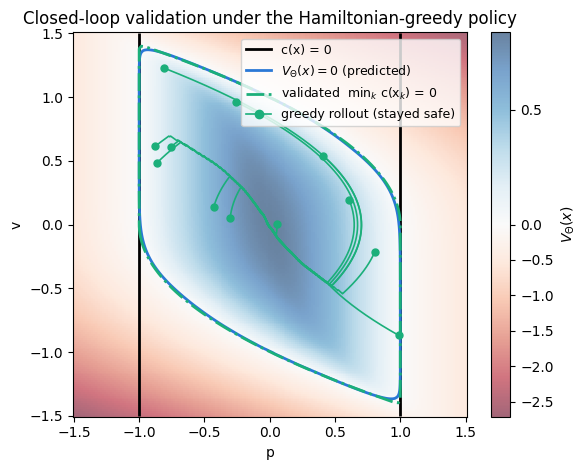

In [15]:
# Validated safe set: roll out from every grid point and keep min_k c(x_k).
Gv, Gv_t = state_grid(100)
rollout = validate_cbf(dyn, Gv_t, constr_fn, model, T=5.0, dt=0.01)
validated_grid = rollout["values"].reshape(100, 100).cpu().numpy()

# A few closed-loop trajectories from predicted-safe initial states.
initial_cbf = result["initial_cbf"].cpu().numpy()
outcome = result["values"].cpu().numpy()
idx = np.where(initial_cbf > 0)[0][:12]
trajs = result["state_traj"][idx].cpu().numpy()

fig, ax = plt.subplots(figsize=(6, 4.8))
im = ax.pcolormesh(G[..., 0], G[..., 1], V_grid, cmap=CMAP_V, norm=norm, shading="auto", rasterized=True, alpha=0.6)
ax.contour(G[..., 0], G[..., 1], constr_on_grid, levels=[0], colors=C_CONSTRAINT, linewidths=2)
ax.contour(G[..., 0], G[..., 1], V_grid, levels=[0], colors=C_LEARNED, linewidths=2)
ax.contour(Gv[..., 0], Gv[..., 1], validated_grid, levels=[0], colors=C_VALIDATED, linewidths=2, linestyles="-.")
for i, tr in zip(idx, trajs):
    col = C_VALIDATED if outcome[i] > 0 else C_UNSAFE
    ax.plot(tr[:, 0], tr[:, 1], color=col, lw=1.2)
    ax.plot(tr[0, 0], tr[0, 1], "o", color=col, ms=5)
fig.colorbar(im, ax=ax, label=r"$V_\Theta(x)$")
ax.legend(handles=[
    Line2D([], [], color=C_CONSTRAINT, lw=2, label="c(x) = 0"),
    Line2D([], [], color=C_LEARNED, lw=2, label=r"$V_\Theta(x) = 0$ (predicted)"),
    Line2D([], [], color=C_VALIDATED, lw=2, ls="-.", label="validated  min$_k$ c(x$_k$) = 0"),
    Line2D([], [], color=C_VALIDATED, lw=1.2, marker="o", label="greedy rollout (stayed safe)"),
], loc="upper right", fontsize=9)
ax.set_xlabel("p"); ax.set_ylabel("v"); ax.set_title("Closed-loop validation under the Hamiltonian-greedy policy")
plt.tight_layout(); plt.show()

## 6. Using the CBF in a safety filter

Downstream, a CBF is used through its value and gradient. A CBF-QP safety filter solves

$$u_{\text{safe}} = \arg\min_{u \in \mathcal{U}} \|u - u_{\text{des}}\|^2
\quad \text{s.t.} \quad \nabla V_\Theta(x)\cdot\big(f(x) + g(x)u\big) + \alpha\, V_\Theta(x) \ge 0 .$$

Both $V_\Theta$ and $\nabla V_\Theta$ come straight from autograd, and `f`, `g` from the
dynamics object, so the constraint is linear in $u$ and any QP solver can be used. For a
scalar control the QP has a closed form (clip $u_{\text{des}}$ to the half-line allowed by the
constraint), which is what we do below: a nominal controller tries to drive the vehicle to
$p = 2$, straight through the wall at $p = 1$; the filter lets it through only as far as
the certified safe set allows.

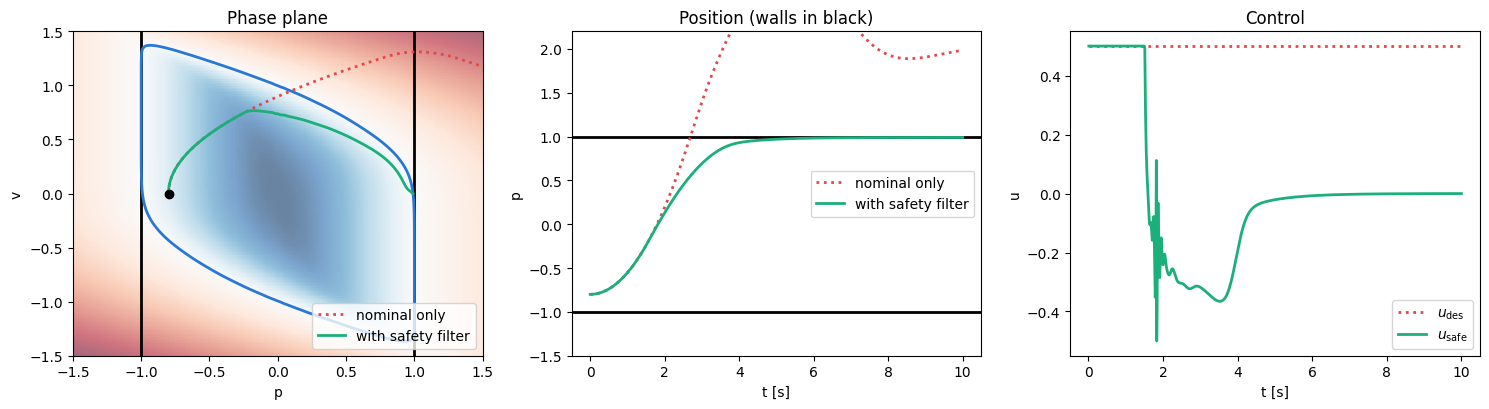

max |p| with filter: 0.9898   (wall at 1.0)
max |p| nominal:     2.8851


In [16]:
def cbf_value_and_grad(x: torch.Tensor):
    x = x.detach().requires_grad_(True)
    v = cbf(x)
    grad = torch.autograd.grad(v.sum(), x)[0]
    return v.detach(), grad.detach()


def safety_filter(x: torch.Tensor, u_des: torch.Tensor, alpha: float = 1.0) -> torch.Tensor:
    # Closed-form CBF-QP for nu == 1.  x: (N, nx), u_des: (N, 1) → (N, 1)
    v, grad = cbf_value_and_grad(x)
    LfV = torch.bmm(grad.unsqueeze(1), dyn.f(x)).reshape(-1)     # ∇V·f(x)
    LgV = torch.bmm(grad.unsqueeze(1), dyn.g(x)).reshape(-1)     # ∇V·g(x)   (scalar since nu == 1)
    u = u_des.reshape(-1).clone()
    bound = -(LfV + alpha * v) / LgV                              # the CBF constraint as a bound on u
    push = LgV > 1e-6                                             # u must be ≥ bound
    pull = LgV < -1e-6                                            # u must be ≤ bound
    u[push] = torch.maximum(u[push], bound[push])
    u[pull] = torch.minimum(u[pull], bound[pull])
    return u.clamp(dyn.u_min[0], dyn.u_max[0]).reshape(-1, 1)   # respect the control box


def nominal_controller(x: torch.Tensor, p_goal: float = 2.0, kp: float = 2.0, kd: float = 1.5) -> torch.Tensor:
    p, v = x[:, 0], x[:, 1]
    return (kp * (p_goal - p) - kd * v).reshape(-1, 1).clamp(dyn.u_min[0], dyn.u_max[0])


def simulate(x0, T=10.0, dt=0.01, use_filter=True):
    x = torch.as_tensor([x0], dtype=torch.float32, device=device)
    xs, us_des, us = [x], [], []
    for _ in range(int(round(T / dt))):
        u_des = nominal_controller(x)
        u = safety_filter(x, u_des) if use_filter else u_des
        x = dyn.euler_step(x, u, dt)
        xs.append(x); us_des.append(u_des); us.append(u)
    return (torch.cat(xs).cpu().numpy(), torch.cat(us_des).cpu().numpy(), torch.cat(us).cpu().numpy())


x0 = (-0.8, 0.0)
xs_f, ud_f, u_f = simulate(x0, use_filter=True)
xs_n, _, _ = simulate(x0, use_filter=False)
t = np.arange(xs_f.shape[0]) * 0.01

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
ax = axes[0]
ax.pcolormesh(G[..., 0], G[..., 1], V_grid, cmap=CMAP_V, norm=norm, shading="auto", rasterized=True, alpha=0.6)
ax.contour(G[..., 0], G[..., 1], constr_on_grid, levels=[0], colors=C_CONSTRAINT, linewidths=2)
ax.contour(G[..., 0], G[..., 1], V_grid, levels=[0], colors=C_LEARNED, linewidths=2)
ax.plot(xs_n[:, 0], xs_n[:, 1], color=C_UNSAFE, lw=2, ls=":", label="nominal only")
ax.plot(xs_f[:, 0], xs_f[:, 1], color=C_VALIDATED, lw=2, label="with safety filter")
ax.plot(*x0, "ko", ms=6)
ax.set_xlim(dyn.x_min[0].item(), dyn.x_max[0].item()); ax.set_ylim(dyn.x_min[1].item(), dyn.x_max[1].item())
ax.set_xlabel("p"); ax.set_ylabel("v"); ax.set_title("Phase plane"); ax.legend(loc="lower right")

ax = axes[1]
ax.axhline(D, color=C_CONSTRAINT, lw=2); ax.axhline(-D, color=C_CONSTRAINT, lw=2)
ax.plot(t, xs_n[:, 0], color=C_UNSAFE, lw=2, ls=":", label="nominal only")
ax.plot(t, xs_f[:, 0], color=C_VALIDATED, lw=2, label="with safety filter")
ax.set_ylim(-1.5, 2.2); ax.set_xlabel("t [s]"); ax.set_ylabel("p"); ax.set_title("Position (walls in black)"); ax.legend()

ax = axes[2]
ax.plot(t[1:], ud_f[:, 0], color=C_UNSAFE, lw=2, ls=":", label=r"$u_\mathrm{des}$")
ax.plot(t[1:], u_f[:, 0], color=C_VALIDATED, lw=2, label=r"$u_\mathrm{safe}$")
ax.set_xlabel("t [s]"); ax.set_ylabel("u"); ax.set_title("Control"); ax.legend()
plt.tight_layout(); plt.show()

print(f"max |p| with filter: {np.abs(xs_f[:, 0]).max():.4f}   (wall at {D})")
print(f"max |p| nominal:     {np.abs(xs_n[:, 0]).max():.4f}")

## 7. Working with YAML configs and checkpoints

For anything beyond a toy, use the scripts: `scripts/train.py --config configs/<system>.yaml`
generates (and caches) the labels, trains, validates and writes
`checkpoints/<GROUP>/<system>/final.pt`. The same YAML can be turned into library objects
with the `build_*` helpers, which is how you load a trained CBF for use elsewhere.

In [17]:
import yaml
from vertexcbf import build_constr_fn, build_dynamics, build_model
from vertexcbf.config_utils import build_trajopt_runner

cfg = yaml.safe_load(open(REPO / "configs" / "inverted_pendulum.yaml"))
dyn_ip = build_dynamics(cfg["system"], device=device)
constr_ip = build_constr_fn(cfg["constraint"])
model_ip = build_model(cfg["model"], dyn_ip, device=device)
print(model_ip)

# The configured label-generation method as a callable on a batch of states:
run_search = build_trajopt_runner(cfg["data"], dyn_ip, constr_ip)
print("labels for 5 random states:", run_search(dyn_ip.get_uniform_state_samples(5)))

ckpt_path = REPO / "checkpoints" / "VRC_DATA" / "inverted_pendulum" / "final.pt"
if ckpt_path.exists():
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=True)
    model_ip.load_state_dict(ckpt["model_state"])
    model_ip.eval()
    print(f"loaded {ckpt_path.relative_to(REPO)}")
else:
    print("no checkpoint yet — train one with:\n"
          "  python scripts/train.py --config configs/inverted_pendulum.yaml")

MLP(periodic_states=[], rescale=True, params=4,353, net=Sequential(
  (0): Linear(in_features=2, out_features=32, bias=True)
  (1): Sin()
  (2): Linear(in_features=32, out_features=32, bias=True)
  (3): Sin()
  (4): Linear(in_features=32, out_features=32, bias=True)
  (5): Sin()
  (6): Linear(in_features=32, out_features=32, bias=True)
  (7): Sin()
  (8): Linear(in_features=32, out_features=32, bias=True)
  (9): Sin()
  (10): Linear(in_features=32, out_features=1, bias=True)
  (11): Softplus(beta=10.0, threshold=20.0)
))
labels for 5 random states: tensor([ 0.0126,  0.0190, -0.2000,  0.0328,  0.1900], device='cuda:0')
no checkpoint yet — train one with:
  python scripts/train.py --config configs/inverted_pendulum.yaml


## 8. Extending: your own system and constraint

A new system is a `ControlAffine` subclass with `nx`, `nu`, `periodic_states`,
`clamp_states` and the two methods `f(x) → (N, nx, 1)` and `g(x) → (N, nx, nu)`. A new
constraint is any function `(N, nx) → (N, 1)` that is positive inside the allowed set.
Nothing else changes — labels, training and validation work exactly as above. To use them
from YAML, add them to `DYNAMICS_REGISTRY` / `CONSTR_REGISTRY` in `vertexcbf/config_utils.py`.

Here: a double integrator with velocity-dependent drag, and an asymmetric position band.

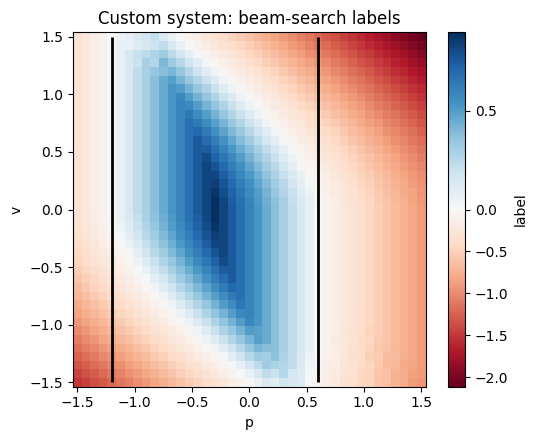

In [18]:
from vertexcbf.dynamics.control_affine import ControlAffine


class DampedDoubleIntegrator(ControlAffine):
    # x = [p, v], u = [a]:  ṗ = v,  v̇ = -k v + a
    name = "damped_double_integrator"
    nx, nu = 2, 1
    periodic_states = []   # indices of angular states (auto-wrapped and (cos, sin)-encoded)
    clamp_states = []      # indices of states to clamp to the state box after each Euler step

    def __init__(self, k: float = 0.5, **kwargs):
        super().__init__(**kwargs)
        self.k = k

    def f(self, x):
        return torch.stack([x[:, 1], -self.k * x[:, 1]], dim=1).unsqueeze(-1)

    def g(self, x):
        return torch.tensor([[0.0], [1.0]], device=self.device, dtype=self.dtype).expand(x.shape[0], -1, -1)


def band_sdf(states, lo: float, hi: float):
    # Allowed region lo <= p <= hi; returns (N, 1), positive inside.
    p = states[..., :1]
    return torch.minimum(p - lo, hi - p)


dyn2 = DampedDoubleIntegrator(k=0.5, x_min=[-1.5, -1.5], x_max=[1.5, 1.5], u_min=[-0.5], u_max=[0.5], device=device)
constr2 = partial(band_sdf, lo=-1.2, hi=0.6)

states2 = dyn2.get_uniform_state_grid([41, 41]).reshape(-1, 2)
values2 = beam_search(dynamics=dyn2, x0=states2, constr_fn=constr2, B=100, K=40, dt=0.1)["values"]

g2 = states2.reshape(41, 41, 2).cpu().numpy()
lab2 = values2.reshape(41, 41).cpu().numpy()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.pcolormesh(g2[..., 0], g2[..., 1], lab2, cmap=CMAP_V,
                   norm=TwoSlopeNorm(vmin=lab2.min(), vcenter=0.0, vmax=lab2.max()), shading="nearest")
ax.contour(g2[..., 0], g2[..., 1], constr2(states2).reshape(41, 41).cpu().numpy(), levels=[0], colors=C_CONSTRAINT, linewidths=2)
fig.colorbar(im, ax=ax, label="label")
ax.set_xlabel("p"); ax.set_ylabel("v"); ax.set_title("Custom system: beam-search labels")
plt.tight_layout(); plt.show()

# From here on, train and validate exactly as in Sections 3-5:
# model2 = MLP(...); Trainer(dynamics=dyn2, model=model2, constr_fn=constr2, data_states=states2, data_values=values2, ...).train()